In [1]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunMod_1k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)

## Escape Momentum

In [2]:
def get_halo_params(sim_folder):

    # Load halo files
    # halo_indices = jnp.load(
    #     f"{sim_folder}/halo_batch_0.6-2.0x1e+12.0_Msun_indices.npy")
    halo_params = jnp.load(
        f"{sim_folder}/halo_batch_0.6-2.0x1e+12.0_Msun_params.npy")

    # Extract halo parameters
    Rvir = halo_params[:,0]  # in kpc
    Mvir = 10**halo_params[:,1]  # in Msun
    conc = halo_params[:,2]  #? unitless

    return Rvir, Mvir, conc


def rho_crit(z, args):

    H_squared = args.H0**2 * (args.Omega_M*(1.+z)**3 + args.Omega_L) 
    rho_crit = 3.*H_squared / (8.*args.Pi*args.G)

    return rho_crit


def scale_density_NFW(c, z, args):
    """Eqn. (2) from arXiv:1302.0288. c=r_200/r_s."""
    numer = 200 * c**3
    denom = 3 * (np.log(1+c) - (c/(1+c)))
    delta_c = numer/denom

    rho_critical = rho_crit(z, args)

    return rho_critical*delta_c


def compute_p_esc(x_i, R_vir, R_s, rho_0, m_nu, args):
    
    # Calculate gravitational potential at coords. x_i.
    r = np.linalg.norm(x_i, axis=-1)
    m = np.minimum(r, R_vir)
    M = np.maximum(r, R_vir)
    prefactor = -4.*args.Pi*args.G*rho_0*R_s**2
    term1 = np.log(1. + (m/R_s)) / (r/R_s)
    term2 = (R_vir/M) / (1. + (R_vir/R_s))
    potential = prefactor * (term1 - term2)

    # Escape momentum formula from Ringwald & Wong (2004).
    p_esc = np.sqrt(2*np.abs(potential)) * m_nu
    y_esc = p_esc/args.T_CNB

    return p_esc, y_esc


def get_p_esc(sim_folder, x_i, m_nu_arr, args):

    # Extract parameters from halos used in simulation folder
    Rvir, Mvir, conc = get_halo_params(sim_folder)
    
    # Only select DM halos used in papers
    exclude_nums = jnp.array([
        20,  # halo with missing/broken snapshot info
        23,  # halo with anomalous number densities (~0s on almost all pixels)
        24,  # anomalous "compactified into 1 cell" DM halo
        25,  # anomalous "compactified into 1 cell" DM halo
    ])

    halo_nums = jnp.array(
        [x for x in range(1, 31) if x not in exclude_nums]) - 1  # subtract 1 for 0-based indexing
    
    Rvir = Rvir[halo_nums]
    Mvir = Mvir[halo_nums]
    conc = conc[halo_nums]

    # Using get_halo_params function, so x_200 values.
    Rs = Rvir/conc
    rho0 = scale_density_NFW(c=conc, z=0., args=args)

    # Compute escape momentum for each halo
    p_escs_l, y_escs_l = [], []
    for m in m_nu_arr:
        p_esc, y_esc = compute_p_esc(
            x_i, 
            Rvir*Params.kpc, 
            Rs*Params.kpc, 
            rho0, m, args)
        p_escs_l.append(p_esc)
        y_escs_l.append(y_esc)

    return jnp.array(p_escs_l).flatten(), jnp.array(y_escs_l).flatten()


def compute_p_esc(x_i, R_vir, R_s, rho_0, m_nu, args):
    """
    Parameters:
    x_i: [..., 3] coordinates
    R_vir: [n_halos] virial radii
    R_s: [n_halos] scale radii
    rho_0: [n_halos] scale densities
    m_nu: [n_masses] neutrino masses
    """
    # Add axes for broadcasting
    R_vir = R_vir[:, None]  # [n_halos, 1]
    R_s = R_s[:, None]      # [n_halos, 1]
    rho_0 = rho_0[:, None]  # [n_halos, 1]
    m_nu = m_nu[None, :]    # [1, n_masses]
    
    # Calculate gravitational potential at coords. x_i
    r = jnp.linalg.norm(x_i, axis=-1)  # [...] 
    m = jnp.minimum(r[..., None, None], R_vir)  # [..., n_halos, 1]
    M = jnp.maximum(r[..., None, None], R_vir)  # [..., n_halos, 1]
    
    prefactor = -4.*args.Pi*args.G*rho_0*R_s**2  # [n_halos, 1]
    term1 = jnp.log(1. + (m/R_s)) / (r[..., None, None]/R_s)  # [..., n_halos, 1]
    term2 = (R_vir/M) / (1. + (R_vir/R_s))  # [..., n_halos, 1]
    potential = prefactor * (term1 - term2)  # [..., n_halos, 1]

    # Escape momentum formula from Ringwald & Wong (2004)
    # Broadcasting: [..., n_halos, 1] * [1, n_masses] -> [..., n_halos, n_masses]
    p_esc = jnp.sqrt(2*jnp.abs(potential)) * m_nu
    y_esc = p_esc/args.T_CNB

    return p_esc, y_esc

def get_p_esc(sim_folder, x_i, m_nu_arr, args):
    # Extract parameters from halos used in simulation folder
    Rvir, Mvir, conc = get_halo_params(sim_folder)
    
    # Only select DM halos used in papers
    exclude_nums = jnp.array([20, 23, 24, 25])
    halo_nums = jnp.array([x for x in range(1, 31) if x not in exclude_nums]) - 1
    
    Rvir = Rvir[halo_nums]  # [n_halos]
    Mvir = Mvir[halo_nums]  # [n_halos]
    conc = conc[halo_nums]  # [n_halos]

    # Using get_halo_params function, so x_200 values
    Rs = Rvir/conc  # [n_halos]
    rho0 = scale_density_NFW(c=conc, z=0., args=args)  # [n_halos]

    # Compute escape momentum for all halos and masses at once
    p_esc, y_esc = compute_p_esc(
        x_i, 
        Rvir*Params.kpc, 
        Rs*Params.kpc, 
        rho0, 
        m_nu_arr, 
        args)
    
    return p_esc, y_esc



# Escape momentum
x_i_Earth = jnp.array([8.127, 0., 0.])*Params.kpc
DM_sim_folder = f"sim_output/Dopri5_1k"
p_esc_arr, y_esc_arr = get_p_esc(DM_sim_folder, x_i_Earth, nu_m_picks, Params())
# print(p_esc_arr, "\n",
#       y_esc_arr)
print(p_esc_arr.shape)
print(y_esc_arr)

(26, 5)
[[0.09003572 0.4501786  0.9003572  1.8007144  2.7010716 ]
 [0.08757413 0.43787066 0.87574132 1.75148264 2.62722397]
 [0.09519792 0.47598958 0.95197916 1.90395831 2.85593747]
 [0.08680108 0.43400542 0.86801085 1.73602169 2.60403254]
 [0.07824697 0.39123484 0.78246968 1.56493936 2.34740905]
 [0.07522771 0.37613854 0.75227709 1.50455417 2.25683126]
 [0.10423031 0.52115156 1.04230312 2.08460625 3.12690937]
 [0.08945475 0.44727377 0.89454754 1.78909507 2.68364261]
 [0.07601265 0.38006324 0.76012648 1.52025295 2.28037943]
 [0.11006817 0.55034085 1.1006817  2.2013634  3.3020451 ]
 [0.09017849 0.45089244 0.90178488 1.80356977 2.70535465]
 [0.08066948 0.40334742 0.80669484 1.61338969 2.42008453]
 [0.09406503 0.47032516 0.94065033 1.88130065 2.82195098]
 [0.10488454 0.52442272 1.04884544 2.09769088 3.14653632]
 [0.1028064  0.514032   1.02806401 2.05612801 3.08419202]
 [0.07570119 0.37850596 0.75701191 1.51402383 2.27103574]
 [0.07657745 0.38288726 0.76577452 1.53154903 2.29732355]
 [0.08

In [3]:
def sim_vels_to_sorted_z0z4(sim_vels, m_nu_arr, merge_last_axes, args):

    # Convert velocities to momenta
    p_arr, y_arr = Physics.velocities_to_momenta_ND_halo_0th_axis(
    v_arr=sim_vels, 
    m_arr=m_nu_arr,
    args=args)

    # Split into arrays for z0 and z4
    p_z0 = p_arr[...,0]
    p_z4 = p_arr[...,-1]
    y_z0 = y_arr[...,0]
    y_z4 = y_arr[...,-1]

    if merge_last_axes:
        p_z0 = p_z0.reshape(*p_z0.shape[:-2], -1)
        p_z4 = p_z4.reshape(*p_z4.shape[:-2], -1)
        y_z0 = y_z0.reshape(*y_z0.shape[:-2], -1)
        y_z4 = y_z4.reshape(*y_z4.shape[:-2], -1)

    # Sort in ascending order of momentum array today
    ind = p_z0.argsort(axis=-1)
    p_z0_sort = jnp.take_along_axis(p_z0, ind, axis=-1)
    p_z4_sort = jnp.take_along_axis(p_z4, ind, axis=-1)
    y_z0_sort = jnp.take_along_axis(y_z0, ind, axis=-1)
    y_z4_sort = jnp.take_along_axis(y_z4, ind, axis=-1)
    
    return ind, p_z0_sort, p_z4_sort, y_z0_sort, y_z4_sort


@jax.jit
def compute_PSDs_day(y_z4_days, y_z0_DM_sim, FD_vals_z0):
    # Vectorize the interpolation across all dimensions
    PSDs_day = Utils.vectorized_interpolate_1D(
        y_z4_days, y_z0_DM_sim, FD_vals_z0)
    return PSDs_day

### Compute original bound percentages

In [ ]:
# Neutrino velocities
halo_num = 10
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, y_z0_DM_sim, _ = sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

# Select most (likely) clustered ones
FD_z0_max = jnp.max(jnp.swapaxes(FD_vals_z0, -1, -2), axis=-1)
FD_median = jnp.median(FD_z0_max, axis=0)

# x-axis
p_z0_select = jnp.swapaxes(p_z0_DM_sim, -1, -2)[..., 0]
p_z0_median = jnp.median(p_z0_select, axis=0)

p_esc_med = jnp.median(p_esc_arr, axis=0)

n_bound_l = []
for mi, p_esc in enumerate(p_esc_med):

    p_z0_med_mi = p_z0_median[mi]
    FD_med_mi = FD_median[mi]

    # Compare momenta to escape momentum
    below_esc = (p_z0_med_mi < p_esc)

    # Select bound values and reshape
    x_bound = p_z0_med_mi[below_esc]
    y_bound = FD_med_mi[below_esc]

    # Compute integral for bound neutrinos
    n_bound = trap(x_bound**3*y_bound, jnp.log(x_bound), axis=-1)
    n_bound_l.append(n_bound)

n_bound = jnp.stack(n_bound_l)

# Compute total (normalization) integral
n_norm = trap(p_z0_median**3*FD_median, jnp.log(p_z0_median), axis=-1)

# Compute percentages
percentages = (n_bound / n_norm) * 100
print([f"{perc:.5f}" for perc in percentages])

### Compute percentages per pixel, per halo, per mass

In [ ]:
### ================== ###
### DM halo simulation ###
### ================== ###

# Neutrino velocities
halo_num = 5
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, _, _ = sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

h_dim, m_dim, p_dim, _ = p_z0_DM_sim.shape

n_bound_l = []
for hi in range(p_esc_arr.shape[0]):  # Loop over halos
    
    n_bound_masses_l = []
    
    for mi in range(p_esc_arr.shape[1]):  # Loop over masses

        p_z0_DM_sim_hi_mi = p_z0_DM_sim[hi, mi, ...]
        FD_vals_z0_hi_mi = FD_vals_z0[hi, mi, ...]
        p_esc_hi_mi = p_esc_arr[hi, mi]
        
        # Compare momenta to escape momentum
        below_esc = (p_z0_DM_sim_hi_mi < p_esc_hi_mi)
        # below_esc = (p_z0_DM_sim_hi_mi >= p_esc_hi_mi)
        
        # Select bound values and reshape
        x_bound = p_z0_DM_sim_hi_mi[below_esc].reshape(p_z0_DM_sim_hi_mi.shape[0], -1)
        y_bound = FD_vals_z0_hi_mi[below_esc].reshape(p_z0_DM_sim_hi_mi.shape[0], -1)
        
        # Compute integral for bound neutrinos
        n_bound = trap(x_bound**3*y_bound, jnp.log(x_bound), axis=-1)
        n_bound_masses_l.append(n_bound)
    
    n_bound_l.append(jnp.stack(n_bound_masses_l))

n_bound = jnp.stack(n_bound_l)  # Final shape: (n_halos, n_masses, n_pixels)
print(n_bound.shape)

# Compute total (normalization) integral
n_norm = trap(p_z0_DM_sim**3*FD_vals_z0, jnp.log(p_z0_DM_sim), axis=-1)

# Compute percentages
percentages_method_1 = (jnp.array(n_bound_l[:len(n_norm)]) / n_norm) * 100
print(percentages_method_1.shape)
print(jnp.median(percentages_method_1, axis=-1))

In [ ]:
### ================== ###
### DM halo simulation ###
### ================== ###

# Neutrino velocities
halo_num = 5
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, _, _ = sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

# Condition for (un)bond neutrinos
esc_cond = (p_z0_DM_sim < p_esc_arr[:halo_num, :, None, None])
# esc_cond = (p_z0_DM_sim >= p_esc_arr[..., None, None])

# Set PSD values to zero, where condition is False
FD_esc = jnp.where(esc_cond, FD_vals_z0, 0.)

# Compute integral for bound neutrinos - will work along last axis for all halos/masses
n_esc = trap(p_z0_DM_sim**3*FD_esc, jnp.log(p_z0_DM_sim), axis=-1)
print(n_esc.shape)

# Compute total (normalization) integral
n_norm = trap(p_z0_DM_sim**3*FD_vals_z0, jnp.log(p_z0_DM_sim), axis=-1)

# Compute percentages
percentages_method_2 = (n_esc / n_norm) * 100
print(percentages_method_2.shape)
print(jnp.median(percentages_method_2, axis=-1))

In [ ]:
(percentages_method_2 - percentages_method_1).min()

In [ ]:
def plot_bound_percentage(percentages, halo_idx, mass_idx, title=None):
    """
    Plot bound neutrino percentages for a specific halo and mass using healpy.

    Parameters:
    -----------
    percentages : array_like
        Array of shape (n_halos, n_masses, n_pixels) containing percentages
    halo_idx : int
        Index of the halo to plot
    mass_idx : int
        Index of the mass to plot
    title : str, optional
        Custom title for the plot. If None, will generate default title
    """
    # Extract the percentages for specific halo and mass (already in percentage units)
    # bound_map = percentages[halo_idx, mass_idx]

    bound_map = jnp.mean(percentages, axis=0)[mass_idx] 

    # Create figure
    plt.figure(figsize=(10, 6))

    # Plot using hp.newvisufunc.projview
    hp.newvisufunc.projview(
        bound_map,
        cmap=cc.cm.CET_L7,
        unit='%',
        title=title or f'Bound neutrino percentage - Halo {halo_idx}, Mass {mass_idx}',
        coord=['G'],
        graticule=True,
        graticule_labels=True,
        xlabel="longitude", 
        ylabel="latitude",
        cb_orientation="horizontal",
        projection_type="mollweide",
        flip='astro',
        latitude_grid_spacing=45,
        longitude_grid_spacing=45,
        phi_convention='counterclockwise',
    )

    print(jnp.mean(bound_map))

    # Adjust colorbar label
    plt.gcf().get_axes()[-1].set_xlabel(r'Bound percentage ($\%$)')

    return plt.gcf()


for i in range(len(nu_m_picks)):
    fig = plot_bound_percentage(percentages, halo_idx=0, mass_idx=i)
    plt.show()

In [ ]:
for i in range(len(nu_m_picks)):
    fig = plot_bound_percentage(percentages, halo_idx=0, mass_idx=i)
    plt.show()

In [10]:
def compute_nu_dens_days(
        days_steps,
        Fermi_Dirac:bool, bound:bool, int_over_pixels:bool):

    # List to store quantities for each day
    days_nrs_l = []
    n_nu_days_l = []
    percs_days_l = []

    # Get Earth velocities w.r.t. the GC, since DM sims are in that frame
    # note: This includes ("inherited") solar system motion
    _, _, earth_vels = SimPlot.SunEarthGC_frame_coords(2024)
    earth_vels *= (Params.km/Params.s)/(Params.kpc/Params.s)

    
    ### ================== ###
    ### DM halo simulation ###
    ### ================== ###

    # Neutrino velocities
    halo_num = 3
    DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

    # Sorted momenta arrays    
    _, p_z0_DM_sim, p_z4_DM_sim, y_z0_DM_sim, _ = sim_vels_to_sorted_z0z4(
        DM_sim_vels, nu_m_picks, 
        merge_last_axes=False, args=Params())

    # PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
    FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
    # (halos, masses, Npix, p_num)

    # Escape momentum
    x_i_Earth = jnp.array([8.127, 0., 0.])*Params.kpc
    p_esc_arr, _ = get_p_esc(sim_folder, x_i_Earth, nu_m_picks, Params())


    ### ==================== ###
    ### Solar modulation sim ###
    ### ==================== ###

    for day in range(0, 365, days_steps):

        # Load velocities for current day
        file_path = f"{sim_folder}/vectors_day{day+1}.npy"

        if os.path.exists(file_path):

            print(f"Day {day+1}/365")
            days_nrs_l.append(day+1)
            
            # Velocities from simulation frame to Earth frame
            # (insert halo dimension at beginning to synchronize)
            day_vels = SimUtil.CNB_to_Earth_frame_trafo(
                jnp.load(file_path)[..., 3:][None, ...],  # sim vels
                earth_vels[day])

            # Sorted momenta arrays
            _, p_z0_days, p_z4_days, _, _ = sim_vels_to_sorted_z0z4(
                day_vels, nu_m_picks, 
                merge_last_axes=False, args=Params())
            
            sort_ind, _, _, _, y_z4_days = sim_vels_to_sorted_z0z4(
                day_vels, nu_m_picks, 
                merge_last_axes=False, args=Params())

            if Fermi_Dirac:
                PSDs_days = Physics.Fermi_Dirac(p_z4_days, Params())

            else:
                # This function needs arrays to have unmerged last axes
                # (so merge_last_axes=False used above for arrays used here)
                PSDs_days = compute_PSDs_day(
                    jnp.repeat(y_z4_days, len(y_z0_DM_sim), axis=0), y_z0_DM_sim, FD_vals_z0)
                
                # Now merge last 2 axes and sort
                # PSDs_days = PSDs_days.reshape(*PSDs_days.shape[:-2], -1)
                PSDs_days = jnp.take_along_axis(PSDs_days, sort_ind, axis=-1)


            ### ================================= ###
            ### Compute number densities for days ###
            ### ================================= ###

            #? some values are above 0.5, some interpolation issue at the edges?
            PSDs_days = jnp.clip(PSDs_days, a_min=None, a_max=0.5)

            if bound:
                # Integrate only up to escape momentum
                # esc_cond = p_z0_days < p_esc_arr[:halo_num, :, None, None]
                esc_cond = p_z0_days >= p_esc_arr[:halo_num, :, None, None]

                # Set PSD values to zero, where condition is False
                if int_over_pixels:
                    PSDs_cond = jnp.where(esc_cond, PSDs_days, 0.)
                else:
                    ...

                # Integral over domain from condition (either bound or unbound)
                n_raw = trap(
                    p_z0_days**3*PSDs_cond, jnp.log(p_z0_days), axis=-1)
                
                # Normalisation integral over total momentum range
                n_norm = trap(
                    p_z0_days**3*PSDs_days, jnp.log(p_z0_days), axis=-1)
            else:
                n_raw = trap(
                    p_z0_days**3*PSDs_days, jnp.log(p_z0_days), axis=-1)


            if int_over_pixels:
                # note: integration over individual pixels
                pix_sr = 4*Params.Pi/simdata.Npix
                n_cm3 = pix_sr*Params.g_nu/((2*jnp.pi)**3)*n_raw/Params.cm**-3
                n_cm3_pix = jnp.array(n_cm3)
                n_tot = jnp.sum(n_cm3_pix, axis=-1)
            else:
                # note: integration over all neutrinos
                pix_sr = 4*Params.Pi
                n_cm3 = pix_sr*Params.g_nu/((2*jnp.pi)**3)*n_raw/Params.cm**-3
                n_tot = jnp.array(n_cm3)

            n_nu_days_l.append(n_tot)

            if bound:
                perc = (n_raw/n_norm)*100
                percs_days_l.append(perc)

        else:
            pass

    days_nrs = jnp.array(days_nrs_l)
    n_nu_days = jnp.array(n_nu_days_l)
    percs_days = jnp.array(percs_days_l)

    return days_nrs, n_nu_days, percs_days


FD_bool = False
bound_bool = True
int_bool = True

days_nrs, n_nu_days, percs_days, = compute_nu_dens_days(
    days_steps=24,  # e.g. 24, 48 96 for faster testing, for all days set to 1
    # days_steps=400,
    Fermi_Dirac=False, bound=True, int_over_pixels=True)

# """
# Helper function to add substring conditionally with underscore handling
def add_if_true(condition, string):
    return f"_{string}" if condition else ""

nu_base_name = "n_nu_days"
nu_filename = (f"{sim_folder}/{nu_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
        #    f"{add_if_true(bound_bool, 'bound')}"
           f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
jnp.save(nu_filename, n_nu_days)

nrs_base_name = "days_nrs"
nrs_filename = (f"{sim_folder}/{nrs_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
        #    f"{add_if_true(bound_bool, 'bound')}"
           f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
jnp.save(nrs_filename, days_nrs)
# """

Day 1/365
Day 25/365
Day 49/365
Day 73/365
Day 97/365
Day 121/365
Day 145/365
Day 169/365
Day 193/365
Day 217/365
Day 241/365
Day 265/365
Day 289/365
Day 313/365
Day 337/365
Day 361/365


In [ ]:
print(percs_days.shape)
mi = 3
print(percs_days[0,0,mi,:].min())
print(jnp.median(percs_days[0,0,mi,:]))
print(percs_days[0,0,mi,:].max())

n_nu_days shape: (16, 3, 5)


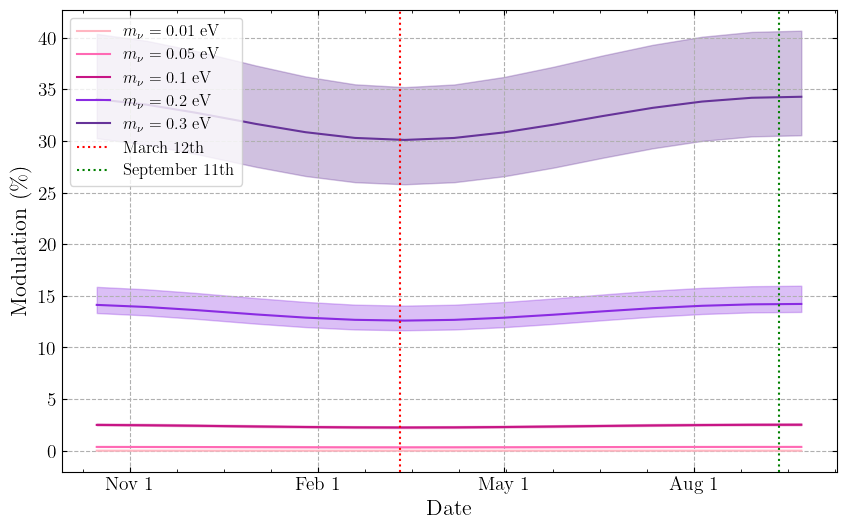

In [16]:
def modulation_band(
        nu_dens_days, simulated_days, nu_m_picks, 
        start_date_str='09-11', mode='modulation'):
    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')
    
    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    # Shift days to start from the specified date
    shifted_days = (simulated_days - start_day_of_year) % 365 + 1
    sorted_indices = jnp.argsort(shifted_days)
    shifted_days = shifted_days[sorted_indices]

    # Adjust vertical lines for March 12th and September 11th
    march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1

    violet_colors = [
        "lightpink",
        "hotpink", 
        "mediumvioletred", 
        "blueviolet",
        "rebeccapurple",
    ]

    for m_idx, (m_val, color) in enumerate(zip(nu_m_picks, violet_colors)):
        
        if FD_bool:
            nu_dens_m = nu_dens_days[:, m_idx]  # (days,)
        else:
            nu_dens_m = nu_dens_days[:, :, m_idx]  # (days, halos)

        #? Since we started from Dec 31st to Jan 1st, we should flip array?
        nu_dens_m = jnp.flip(nu_dens_m, axis=0)

        # Compute fractional modulation for each halo
        nu_min = jnp.min(nu_dens_m, axis=0)
        mod = (nu_dens_m - nu_min) / (nu_dens_m + nu_min) * 100

        if mode == 'densities':
            mod = nu_dens_m

        # Sort modulation values for each day
        # mod_sorted = jnp.sort(mod, axis=1)

        # Compute median and 1-sigma band
        median = jnp.median(mod, axis=-1)
        lower = jnp.percentile(mod, 16, axis=-1)
        upper = jnp.percentile(mod, 84, axis=-1)

        # Apply sorting to match shifted_days
        median = median[sorted_indices]
        lower = lower[sorted_indices]
        upper = upper[sorted_indices]

        # Plot median and 1-sigma band
        ax.plot(shifted_days, median, '-', color=color, label=fr"$m_\nu = {m_val}$ eV")
        ax.fill_between(shifted_days, lower, upper, color=color, alpha=0.3)

    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']

    plt.xticks(tick_days, tick_labels)

    # Set axis limits and labels
    # plt.ylim(0, 1)
    plt.ylabel(r'Modulation ($\%$)')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, which="major", linestyle="dashed")

    plt.axvline(x=march_12, color='r', linestyle=':', label='March 12th')
    plt.axvline(x=sept_11, color='g', linestyle=':', label='September 11th')

    plt.legend(prop={"size":12})

    plt.savefig(
        f"{fig_folder}/modulation_1year_Earth_frame_{start_date_str}start_band.pdf",
        bbox_inches="tight")

    plt.show()
    plt.close()


FD_bool = False
bound_bool = True
int_bool = True

# Helper function to add substring conditionally with underscore handling
def add_if_true(condition, string):
    return f"_{string}" if condition else ""

nu_base_name = "n_nu_days"
nu_filename = (f"{sim_folder}/{nu_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
           f"{add_if_true(bound_bool, 'bound')}"
        #    f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
n_nu_days = jnp.load(nu_filename)

nrs_base_name = "days_nrs"
nrs_filename = (f"{sim_folder}/{nrs_base_name}"
           f"{add_if_true(FD_bool, 'FD')}"
           f"{add_if_true(bound_bool, 'bound')}"
        #    f"{add_if_true(bound_bool, 'unbound')}"
           f"{add_if_true(int_bool, 'int_pixels')}"
           ".npy")
days_nrs = jnp.load(nrs_filename)

print(f"n_nu_days shape: {n_nu_days.shape}")

# Call the modulation function with the full n_nu_days array
modulation_band(
    # nu_dens_days=n_nu_days/Params.N0_cm3, 
    nu_dens_days=n_nu_days, 
    simulated_days=days_nrs, 
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities'
)